# Семинар 7 - Детекция и сопоставление ключевых точек

Данный семинар содержит две части: первая с неоцениваемыми опциональными заданиями, и вторая часть с **Домашним заданием**

***

In [ ]:
import numpy as np
from scipy import ndimage, stats
from time import perf_counter
import cv2
import matplotlib.pyplot as plt
from itertools import product
import hashlib

sha = lambda a: hashlib.sha256(a.tobytes()).hexdigest()

# Данные

Изображения взяты из папки samples репозитория opencv: https://github.com/opencv/opencv/tree/4.x/samples/data

In [ ]:
!mkdir data
!wget https://github.com/opencv/opencv/raw/4.x/samples/data/box.png -O ./data/box.png
!wget https://github.com/opencv/opencv/raw/4.x/samples/data/box_in_scene.png -O ./data/box_in_scene.png

In [ ]:
img_1 = cv2.imread('data/box.png', cv2.IMREAD_GRAYSCALE)

img_2 = cv2.imread('data/box_in_scene.png', cv2.IMREAD_GRAYSCALE)

In [ ]:
plt.figure(figsize=[10, 10])
plt.subplot(1, 2, 1)
plt.imshow(img_1, cmap='Greys_r')
plt.subplot(1, 2, 2)
plt.imshow(img_2, cmap='Greys_r')

In [ ]:
img_1.shape

# Извлечение ключевых точек: ORB

- Rublee, Ethan, et al. "ORB: An efficient alternative to SIFT or SURF." 2011 International conference on computer vision. Ieee, 2011. [[pdf]](https://d1wqtxts1xzle7.cloudfront.net/63685366/ORB-_An_efficient_alternative_to_SIFT_or_SURF20200619-118758-d5kgfr-libre.pdf?1592635646=&response-content-disposition=inline%3B+filename%3DORB_an_efficient_alternative_to_SIFT_or.pdf&Expires=1678814267&Signature=bylBe0Mp4cefN84Bzcx1RZP0mUe7ZGLkYFAYAZ1~rbgXQtNFXbMryWE-FcG~sYLMhk9hKdwGVzvgLYGb-OZazU5dcsurJl7Fw4Csg7lThUE8Kh~SYK9fqG8XrMpQlUn3hIMrobrTH9qvAMeVBNs0ZCTPmvFI5o04OW73ysIS6BoX0nsLMUxtYZa8zvIJvZJSey6POYB8-IXQO8Jvu0e3mvzwViUXxvByCJwycTHC1oObfH6mFU6cg4A0SPUNdiKdmZOvx0nmhvY96NRuu7aMX8I6mrU6x02NBQZtTRebP3RoQqtBhr-5X~c40uxY-big5AnZu2fc-qP8OWZ0lnx~xg__&Key-Pair-Id=APKAJLOHF5GGSLRBV4ZA)

[Туториал на medium](https://medium.com/@deepanshut041/introduction-to-orb-oriented-fast-and-rotated-brief-4220e8ec40cf)



In [ ]:
# Initiate ORB detector
orb = cv2.ORB_create()

# find the keypoints and descriptors with ORB
kp_1, des_1 = orb.detectAndCompute(img_1, None)
kp_2, des_2 = orb.detectAndCompute(img_2, None)

Каждая ключевая точка характеризуется:
1. angle - углом, что позволяет вычислять дескрипторы, инвариантные к повороту,
2. octave - октавой, определяющей масштаб, на котором была обнаружена ключевая точка,
3. pt - субпиксельными координатами этой ключевой точки на изображении, 
4. response - величиной отклика детектора,
5. size - размером (для визуализации величины отклика)

In [ ]:
print('type(kp_1) =', type(kp_1))
print('len(kp_1) =', len(kp_1))
print()
print('kp_1[0] =', kp_1[0])
print()
print('kp_1[0].angle = ', kp_1[0].angle)
print('kp_1[0].octave = ', kp_1[0].octave)
print('kp_1[0].pt = ', kp_1[0].pt)
print('kp_1[0].response = ', kp_1[0].response)
print('kp_1[0].size = ', kp_1[0].size)

Дескрипторы - это вектора фиксированной длины для каждой ключевой точки

In [ ]:
print('type(des_1) =', type(des_1))
print('des_1.shape =', des_1.shape)
print('des_1.dtype =', des_1.dtype)

In [ ]:
img_1_kp = cv2.drawKeypoints(img_1, kp_1, None, (255, 0, 0), 4)
img_2_kp = cv2.drawKeypoints(img_2, kp_2, None, (255, 0, 0), 4)

In [ ]:
plt.figure(figsize=[10, 10])
plt.imshow(img_1_kp)

In [ ]:
plt.figure(figsize=[10, 10])
plt.imshow(img_2_kp)

# Вопрос 1

_(самостоятельная работа без проверки и оценки)_

О чем говорит наличие концентрических окружностей?

**Ответ:** Разные размеры точек

# Вопрос 2

_(самостоятельная работа без проверки и оценки)_

Каким способом можно избавиться от избыточных близких ключевых точек? И нужно ли это делать?

**Ответ:** Non maximum supression

# Сопоставление ключевых точек: Brute-Force

[Туториал OpenCV по Feature Matching](https://docs.opencv.org/3.0-beta/doc/py_tutorials/py_feature2d/py_matcher/py_matcher.html#)

Для сопоставления ключевых точек методом грубого перебора можно использовать функцию `cv2.BFMatcher()`.

Она принимает на вход два аргумента:
1. `normType` - какая меру дистанции между дескрипторами будет использоваться
2. `crossCheck` - при значении `True` возвращает только пары (i, j), такие, что i-й дескриптор из первого имеет в качестве наилучшего совпадения j-й дескриптор из второго множества (и наоборот).

In [ ]:
matcher = cv2.BFMatcher(cv2.NORM_HAMMING2, crossCheck=True)
matches = matcher.match(des_1, des_2)

# top-20 matches
matches = sorted(matches, key=lambda x: x.distance)
matches = matches[:20]

In [ ]:
img_matches = cv2.drawMatches(img_1, kp_1, img_2, kp_2, matches, None, flags=2)

In [ ]:
plt.figure(figsize=[10, 10])
plt.imshow(img_matches)

# Выравнивание изображений

In [ ]:
src_pts = np.float32([ kp_1[m.queryIdx].pt for m in matches ]).reshape(-1,1,2)
dst_pts = np.float32([ kp_2[m.trainIdx].pt for m in matches ]).reshape(-1,1,2)

M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

In [ ]:
M

In [ ]:
img_1_transformed = cv2.warpPerspective(img_1, M, img_2.shape[0:2][::-1])

In [ ]:
plt.figure(figsize=[20, 10])
plt.subplot(2, 1, 1)
plt.imshow(img_1_transformed, cmap='Greys_r')
plt.subplot(2, 1, 2)
plt.imshow(img_2, cmap='Greys_r')

# SURF

Основные отличия между детекторами ORB (Oriented FAST and Rotated BRIEF) и SURF (Speeded Up Robust Features) заключаются в следующем:

- Скорость: ORB быстрее, чем SURF. Это связано с тем, что ORB использует бинарный дескриптор и более быстрый алгоритм обнаружения ключевых точек (FAST), в то время как SURF использует дескриптор с плавающей запятой и более вычислительно сложный алгоритм обнаружения ключевых точек.
- Инвариантность к масштабу: SURF обладает более высокой инвариантностью к масштабу, чем ORB. Это связано с тем, что SURF использует представление изображения в масштабированном виде (scale-space representation of the image) для обнаружения ключевых точек на разных масштабах, тогда как ORB использует фиксированный размер пирамиды масштабов (fixed-size scale pyramid).
- Инвариантность к повороту: ORB более инвариантен к повороту, чем SURF. ORB вычисляет дескриптор, который инвариантен к повороту, в то время как SURF вычисляет дескриптор, который не полностью инвариантен к повороту, но может быть сделан таковым с помощью дополнительных вычислений.
- Устойчивость к шуму и размытию: SURF в целом более устойчив к шуму и размытию, чем ORB, из-за использования в процессе обнаружения ключевых точек гауссовского фильтра.

[Туториал на medium](https://medium.com/@deepanshut041/introduction-to-surf-speeded-up-robust-features-c7396d6e7c4e)

**Основным заданием** будет ознакомиться со статьями:

1. [Speeded-Up Robust Features (SURF)](https://www.sciencedirect.com/science/article/pii/S1077314207001555)
2. [An Analysis of the SURF Method](https://www.ipol.im/pub/art/2015/69/article_lr.pdf) (опционально, расширенный анализ метода)

Опираясь на статьи, необходимо дополнить недостающие строчки кода. Во многих местах достаточно одной строки, реализующей ту или иную операцию.

Сначала ознакомьтесь со вспомогательными функциями:

In [ ]:
def integral_image(image):
    '''Вычисляет интегральное изображение
    '''
    return image.cumsum(axis=0).cumsum(axis=1)


def partial_sums(integral, x, y, w, h, kernel_size, spatial_step):
    '''Вычисляет свертку изображения на основе интегрального изображения.
    Ядро свертки имеет размер kernel_size x kernel_size и движется
    с шагом spatial_step.

    По изображению движется ядро размера kernel_size x kernel_size
    с шагом spatial_step. Это ядро состоит из нулей, кроме прямоугольника
    с верхним левым углом (x, y) и размерами (ширина, высота) = (w, h).
    '''
    H, W = integral.shape[:2]
    integral = np.pad(integral, 1)
    x, y = x + 1, y + 1

    y1 = y - 1
    y2 = H - (kernel_size - y1) + 1
    x1 = x - 1
    x2 = W - (kernel_size - x1) + 1
    b1 = integral[y1:y2:spatial_step, x1:x2:spatial_step]

    y1 = y - 1
    y2 = H - (kernel_size - y1) + 1
    x1 = x + w - 1
    x2 = W - (kernel_size - x1) + 1
    b2 = integral[y1:y2:spatial_step, x1:x2:spatial_step]

    y1 = y + h - 1
    y2 = H - (kernel_size - y1) + 1
    x1 = x - 1
    x2 = W - (kernel_size - x1) + 1
    b3 = integral[y1:y2:spatial_step, x1:x2:spatial_step]

    y1 = y + h - 1
    y2 = H - (kernel_size - y1) + 1
    x1 = x + w - 1
    x2 = W - (kernel_size - x1) + 1
    b4 = integral[y1:y2:spatial_step, x1:x2:spatial_step]

    return b4 - b2 - b3 + b1

# Задание 1: Вспомогательные функции

_(самостоятельная работа без проверки и оценки)_

Допишите оператор return в тех функциях, где это необходимо.

In [ ]:
def Dx(integral, kernel_size):
    '''Первая производная по X
    '''
    left = partial_sums(integral, 0, 0, kernel_size // 2, kernel_size, kernel_size, 1)
    right = partial_sums(integral, kernel_size // 2, 0, kernel_size // 2, kernel_size, kernel_size, 1)
    return ...  # <============1==============


def Dy(integral, kernel_size):
    '''Первая производная по Y
    '''
    up = partial_sums(integral, 0, 0, kernel_size, kernel_size // 2, kernel_size, 1)
    bottom = partial_sums(integral, 0, kernel_size // 2, kernel_size, kernel_size // 2, kernel_size, 1)
    return ...  # <============2==============


def Dxx(integral, kernel_size, spatial_step):
    '''Вторая производная по X
    '''
    shift = round(kernel_size * 2 / 9)
    h = kernel_size - 2 * shift

    w1 = round(kernel_size / 3)
    w2 = round(kernel_size / 3)
    w3 = kernel_size - w1 - w2

    c1 = (3 * 5) / (w1 * h)
    c2 = (3 * 5) / (w2 * h)
    c3 = (3 * 5) / (w3 * h)

    left = partial_sums(integral, 0, shift, w1, h, kernel_size, spatial_step)
    center = partial_sums(integral, 0 + w1, shift, w2, h, kernel_size, spatial_step)
    right = partial_sums(integral, 0 + w1 + w2, shift, w3, h, kernel_size, spatial_step)

    return ...  # <============3==============


def Dyy(integral, kernel_size, spatial_step):
    '''Вторая производная по Y
    '''
    shift = round(kernel_size * 2 / 9)
    w = kernel_size - 2 * shift

    h1 = round(kernel_size / 3)
    h2 = round(kernel_size / 3)
    h3 = kernel_size - h1 - h2

    c1 = (3 * 5) / (h1 * w)
    c2 = (3 * 5) / (h2 * w)
    c3 = (3 * 5) / (h3 * w)

    top = partial_sums(integral, shift, 0, w, h1, kernel_size, spatial_step)
    center = partial_sums(integral, shift, 0 + h1, w, h2, kernel_size, spatial_step)
    bottom = partial_sums(integral, shift, 0 + h1 + h2, w, h3, kernel_size, spatial_step)

    return ...  # <============4==============


def Dxy(integral, kernel_size, spatial_step):
    '''Смешанная производная по XY
    '''
    shift_1 = round(kernel_size * 1 / 9)
    shift_2 = round(kernel_size * 5 / 9)
    size = round(kernel_size * 3 / 9)

    c = (3 * 3) / (size * size)

    b11 = partial_sums(integral, shift_1, shift_1, size, size, kernel_size, spatial_step)
    b21 = partial_sums(integral, shift_1, shift_2, size, size, kernel_size, spatial_step)
    b12 = partial_sums(integral, shift_2, shift_1, size, size, kernel_size, spatial_step)
    b22 = partial_sums(integral, shift_2, shift_2, size, size, kernel_size, spatial_step)

    return ...  # <============5==============


def det_H_approx(integral, kernel_size, spatial_step):
    '''Приближенное значение определителя гессиана
    '''
    Dxx_image = Dxx(integral, kernel_size, spatial_step)
    Dyy_image = Dyy(integral, kernel_size, spatial_step)
    Dxy_image = Dxy(integral, kernel_size, spatial_step)
    return ...  # <=6= equations 3 and 4 of [1]


def haar_approx(integral, kernel_size):
    Dx_image = Dx(integral, kernel_size)
    Dy_image = Dy(integral, kernel_size)
    return np.stack((Dx_image, Dy_image), axis=0)

Проверьте правильность реализации:

In [ ]:
img_test = img_1[:100, :100]
integral = integral_image(img_test)

a = Dx(integral, 9)
assert(a.shape == (92, 92))
assert(sha(a) == '8443801ac6710847e145b1475ab5b46c62ffbf93a7c9f3cb6c6545e472b3055c')

a = Dy(integral, 9)
assert(a.shape == (92, 92))
assert(sha(a) == '86efd03cc4121d3971ae815d1313a747afbc2a2f731439a4fdbccb023c12ea91')

a = Dxx(integral, 9, 2)
assert(a.shape == (46, 46))
assert(sha(a) == '6bc290652bdc4097d0c586156bf34be79c6bc7bb4349deb81825906e05d990c4')

a = Dyy(integral, 9, 2)
assert(a.shape == (46, 46))
assert(sha(a)== '32eb1373fa7cfb32bd73ae4c488a06ccf60aea2c54a5506b0b5a1fe7b012fb71')

a = Dxy(integral, 9, 2)
assert(a.shape == (46, 46))
assert(sha(a) == '67117a8e240a7621d9a587ad657c782fef9496d4116bed831e178024b4fb7202')

a = det_H_approx(integral, 9, 2)
assert(a.shape == (46, 46))
assert(sha(a) == 'ee35655b446302b24b7c820f4f5268d8aff1ed81ae7d5947ca0ec464dcb68497')

# Задание 2: Детектор ключевых точек

_(самостоятельная работа без проверки и оценки)_

1. В функции _init_pyramid заполните параметры пирамиды изображений правильными значениями
2. Релизуйте функцию _is_maxima, проверяющую, что центральный элемент кубика N27 размера 3x3x3, является максимальными среди всех элементов N27
3. Допишите функцию _interpolate_keypoint, вычисляющую положение субпиксельного максимума в N27

In [ ]:
class FastHessianDetector:

    def __init__(self, hessian_threshold, n_octaves=4, n_octave_layers=4):
        self.hessian_threshold = hessian_threshold
        self.n_octaves = n_octaves
        self.n_octave_layers = n_octave_layers
        self.pyramid = None

        self.pyramid_internal_layers = []
        self.pyramid_parameters = []
        self._init_pyramid()

    def detect(self, image):
        pyramid = self._build_pyramid(image.astype(np.float32))

        keypoints = []
        for internal_layer in self.pyramid_internal_layers:
            layer_keypoints = self._extract_layer_keypoints(pyramid, internal_layer)
            keypoints.extend(layer_keypoints)

        return keypoints

    def _init_pyramid(self):
        index = 0
        for octave in range(1, self.n_octaves + 1):
            for layer in range(1, self.n_octave_layers + 1):
                kernel_size = ...   # <= section 3.3 of [1]; table 2 of [2]
                spatial_step = ...  # <= section 3.3 of [1]; section 4.1 (sampling) of [2]
                scale = ...         # <= eq. 20 of [2]
                scale_step = ...    # <= step between two scales in one layer
                self.pyramid_parameters.append((kernel_size, spatial_step, scale, scale_step))
                if 1 < layer < self.n_octave_layers:
                    self.pyramid_internal_layers.append(index)
                index += 1

    def _build_pyramid(self, image):
        padding = (max([kernel_size for kernel_size, spatial_step, scale, scale_step in self.pyramid_parameters]) - 1) // 2
        imgage_padded = np.pad(image, padding)

        integral = integral_image(imgage_padded)
        H, W = integral.shape

        pyramid = []
        for kernel_size, spatial_step, scale, scale_step in self.pyramid_parameters:
            empty_size = padding - (kernel_size - 1) // 2
            pyramid_layer = det_H_approx(
                integral[empty_size:H - empty_size, empty_size:W - empty_size],
                kernel_size,
                spatial_step
            )
            pyramid.append(pyramid_layer)

        return pyramid

    def _extract_layer_keypoints(self, pyramid, internal_layer):
        H, W = pyramid[internal_layer].shape

        layer_keypoints = []
        maximas = []
        for y in range(1, H - 1):
            for x in range(1, W - 1):
                N27 = self._get_N27(pyramid, internal_layer, x, y)
                magnitude = N27[1, 1, 1]
                if self._is_maxima(N27) and magnitude >= self.hessian_threshold:
                    status, local_keypoint = self._interpolate_keypoint(N27)
                    if status:
                        keypoint = self._project_keypoint(local_keypoint, internal_layer, x, y)
                        layer_keypoints.append(keypoint)
                        maximas.append(magnitude)
        layer_keypoints = [layer_keypoints[i] for i in np.argsort(maximas)[::-1]]
        return layer_keypoints

    def _get_N27(self, pyramid, internal_layer, x, y):
        l = internal_layer
        N27 = np.array([[
            [pyramid[l - 1][y - 1, x - 1], pyramid[l - 1][y - 1, x], pyramid[l - 1][y - 1, x + 1]],
            [pyramid[l - 1][y, x - 1],     pyramid[l - 1][y, x],     pyramid[l - 1][y, x + 1]],
            [pyramid[l - 1][y + 1, x - 1], pyramid[l - 1][y + 1, x], pyramid[l - 1][y + 1, x + 1]]
        ], [
            [pyramid[l][y - 1, x - 1], pyramid[l][y - 1, x], pyramid[l][y - 1, x + 1]],
            [pyramid[l][y, x - 1],     pyramid[l][y, x],     pyramid[l][y, x + 1]],
            [pyramid[l][y + 1, x - 1], pyramid[l][y + 1, x], pyramid[l][y + 1, x + 1]]
        ], [
            [pyramid[l + 1][y - 1, x - 1], pyramid[l + 1][y - 1, x], pyramid[l + 1][y - 1, x + 1]],
            [pyramid[l + 1][y, x - 1],     pyramid[l + 1][y, x],     pyramid[l + 1][y, x + 1]],
            [pyramid[l + 1][y + 1, x - 1], pyramid[l + 1][y + 1, x], pyramid[l + 1][y + 1, x + 1]]
        ]])
        return N27

    def _is_maxima(self, N27):  # <= section 3.4 of [1]; check whether the central element of 3x3x3 cube is maximum
        ...
        return ...

    def _interpolate_keypoint(self, N27):  # <= section 4.3 of [2]
        dL_dx = ...        # <= the function is already implemented, only need to call
        d2L_d2x = ...      # <= the function is already implemented, only need to call
        try:
            local_keypoint = ...   # <= solve the quadratic equation (see section 4.3 of [2])
            status = (np.abs(local_keypoint) <= 1).all()
        except np.linalg.LinAlgError:
            local_keypoint = None
            status = False
        return status, local_keypoint

    def _first_derivative(self, N27, axis):
        index_0, index_2 = [1, 1, 1], [1, 1, 1]
        index_0[axis] = 0
        index_2[axis] = 2
        index_0, index_2 = tuple(index_0), tuple(index_2)
        return (N27[index_2] - N27[index_0]) / 2

    def _gradient(self, N27):
        return np.array([self._first_derivative(N27, axis) for axis in range(3)])

    def _second_derivative(self, N27, axes):
        if axes[0] == axes[1]:
            return self._double_derivative(N27, axes[0])
        else:
            return self._mixed_derivative(N27, axes)

    def _double_derivative(self, N27, axis):
        index_0, index_2 = [1, 1, 1], [1, 1, 1]
        index_0[axis] = 0
        index_2[axis] = 2
        index_0, index_2 = tuple(index_0), tuple(index_2)
        return N27[index_2] - 2 * N27[1, 1, 1] + N27[index_0]

    def _mixed_derivative(self, N27, axes):
        index_0_0, index_2_0 = [1, 1, 1], [1, 1, 1]
        index_0_0[axes[0]] = 0
        index_2_0[axes[0]] = 2
        index_0_0[axes[1]] = index_2_0[axes[1]] = 0
        index_0_0, index_2_0 = tuple(index_0_0), tuple(index_2_0)

        index_0_2, index_2_2 = [1, 1, 1], [1, 1, 1]
        index_0_2[axes[0]] = 0
        index_2_2[axes[0]] = 2
        index_0_2[axes[1]] = index_2_2[axes[1]] = 2
        index_0_2, index_2_2 = tuple(index_0_2), tuple(index_2_2)

        return ((N27[index_2_2] - N27[index_0_2]) - (N27[index_2_0] - N27[index_0_0])) / 4

    def _hessian(self, N27):
        return np.array([
            self._second_derivative(N27, axes) for axes in product(range(3), repeat=2)
        ]).reshape(3, 3)

    def _project_keypoint(self, local_keypoint, internal_layer, x, y):
        kernel_size, spatial_step, scale, scale_step = self.pyramid_parameters[internal_layer]
        local_scale, local_x, local_y = local_keypoint

        scale = scale + local_scale * scale_step
        x = (x + local_x + 0.5) * spatial_step
        y = (y + local_y + 0.5) * spatial_step

        return [scale, x, y]

Проверьте правильность реализации:

In [ ]:
detector = FastHessianDetector(1000000, n_octaves=3)

img_test = img_1.copy()

keypoints = detector.detect(img_test)

a = np.array(keypoints)

# отдельным челленджем для Вас может стать задача получить результат в точности, как у меня
# для этого я оставил здесь эти ассерты
# но это не обязательно - вы можете решить задачу чуть-чуть иначе, но при этом логически правильно

# assert(a.shape == (126, 3))
# assert(sha(a) == '91724ac19651c85852e8de4d8f9a99f65a1ef825d5a03fe0e81821451708d109')

# Задание 3: Оценка ориентации ключевых точек

1. В функции _init_pyramid заполните параметры пирамиды изображений правильными значениями
2. В функции _estimate_orientation допишите расчет радиуса окресности точки (2.a) и параметров нормального распределения (2.b), задающего вес точек в этой окрестности, через масштаб, на котором обнаружена ключевая точка, а также допишите вычисление нормы градиента (2.c).

In [ ]:
class OrientationEstimator:

    def __init__(self, n_octaves=4, n_octave_layers=4):
        self.n_octaves = n_octaves
        self.n_octave_layers = n_octave_layers

        self.pyramid_parameters = []
        self._init_pyramid()

    def _init_pyramid(self):
        for octave in range(1, self.n_octaves + 1):
            for layer in range(1, self.n_octave_layers + 1):
                scale = ...         # <=1= уже было выше
                kernel_size = ...   # <=1= section 4.1 of [1]; convert to int()
                kernel_size += kernel_size % 2
                self.pyramid_parameters.append((scale, kernel_size))

    def estimate(self, image, keypoints):
        pyramid = self._build_pyramid(image.astype(np.float32))

        oriented_keypoints = []
        for keypoint in keypoints:
            orientation = self._estimage_orientation(pyramid, keypoint)
            oriented_keypoints.append((keypoint + [orientation]))

        return oriented_keypoints

    def _build_pyramid(self, image):
        padding = max([kernel_size for scale, kernel_size in self.pyramid_parameters]) // 2
        imgage_padded = np.pad(image, padding)

        integral = integral_image(imgage_padded)
        H, W = integral.shape

        pyramid = []
        for scale, kernel_size in self.pyramid_parameters:
            empty_size = padding - kernel_size // 2
            pyramid_layer = haar_approx(
                integral[empty_size:H - empty_size, empty_size:W - empty_size],
                kernel_size
            )
            pyramid.append(pyramid_layer)

        return pyramid

    def _estimage_orientation(self, pyramid, keypoint):
        scale, x, y = keypoint
        layer = self._find_nearest_layer(scale)
        Dx_image, Dy_image = pyramid[layer]

        center = int(x), int(y)
        radius = ...   # <=2.a= section 4.1 of [1]

        Dx_polar = cv2.linearPolar(Dx_image, center, radius, cv2.WARP_FILL_OUTLIERS)
        Dy_polar = cv2.linearPolar(Dy_image, center, radius, cv2.WARP_FILL_OUTLIERS)

        Dx_polar = ndimage.interpolation.zoom(Dx_polar, (360 / Dx_polar.shape[0], int(radius) / Dx_polar.shape[1]))
        Dy_polar = ndimage.interpolation.zoom(Dy_polar, (360 / Dy_polar.shape[0], int(radius) / Dy_polar.shape[1]))

        sigma = ...   # <=2.b= section 4.1 of [1]
        gauss_kernel = stats.norm(scale=sigma).pdf(np.arange(0, int(radius)))
        Dx_polar = (Dx_polar * gauss_kernel).sum(axis=1)
        Dy_polar = (Dy_polar * gauss_kernel).sum(axis=1)

        Dx_polar = np.concatenate((Dx_polar, Dx_polar[:60]), axis=0)
        Dy_polar = np.concatenate((Dy_polar, Dy_polar[:60]), axis=0)

        Dx_polar_cm = Dx_polar.cumsum(axis=0)
        Dy_polar_cm = Dy_polar.cumsum(axis=0)

        Dx_sum = Dx_polar_cm[60:] - Dx_polar_cm[:-60]
        Dy_sum = Dy_polar_cm[60:] - Dy_polar_cm[:-60]

        grad_norm = ...   # <=2.c= section 5.2 (Orientation score function) of [2]

        orientation = (np.argmax(grad_norm) + 30) % 360

        return orientation

    def _find_nearest_layer(self, scale):
        layer = min([(np.abs(scale - s), layer)
            for layer, (s, _) in enumerate(self.pyramid_parameters)])[1]
        return layer

Проверьте правильность реализации:

In [ ]:
estimator = OrientationEstimator()

oriented_keypoints = estimator.estimate(img_test, keypoints)

a = np.array(oriented_keypoints)

# отдельным челленджем для Вас может стать задача получить результат в точности, как у меня
# для этого я оставил здесь эти ассерты
# но это не обязательно - вы можете решить задачу чуть-чуть иначе, но при этом логически правильно

# assert(a.shape == (126, 4))
# assert(sha(a) == 'd24fcfafbc3d194b8da5e2fae3d85a1e376509a10245e440d54c823cb2acd7a8')

# Задание 4: Формирование SURF дескриптора

В функции вычисления дескриптора сформируйте:
1. sigma - параметр нормального распределения, определяющего веса градиентов в окрестности точки
2. Dx_image, Dy_image - перевзвешенные градиетны с гауссовыми весами
3. Сохранение дескриптора

In [ ]:
class SURFDescriptor:

    def compute(self, image, keypoints):
        descriptors = []
        for scale, x, y, orientation in keypoints:
            kernel_size = int(2 * scale)
            kernel_size += kernel_size % 2
            window_size = int(20 * scale)
            window_size += 4 - window_size % 4

            u = np.cos(np.pi * orientation / 180), np.sin(np.pi * orientation / 180)
            v = np.sin(np.pi * orientation / 180), -np.cos(np.pi * orientation / 180)
            src = np.array([
                [x + (u[0] + v[0]) * window_size, y + (u[1] + v[1]) * window_size],
                [x + (u[0] - v[0]) * window_size, y + (u[1] - v[1]) * window_size],
                [x + (-u[0] - v[0]) * window_size, y + (-u[1] - v[1]) * window_size],
                [x + (-u[0] + v[0]) * window_size, y + (-u[1] + v[1]) * window_size]
            ], dtype=np.float32)
            dst = np.array([[0, 0], [0, window_size], [window_size, window_size], [window_size, 0]], dtype=np.float32)
            M = cv2.getPerspectiveTransform(src, dst)

            patch = cv2.warpPerspective(image, M, (window_size, window_size))
            patch = np.pad(patch, kernel_size // 2)

            integral = integral_image(patch)
            Dx_image = Dx(integral, kernel_size)[:-1, :-1]
            Dy_image = Dy(integral, kernel_size)[:-1, :-1]

            sigma = ...  # <=1= section 4.2 of [1]
            gauss_kernel = stats.norm(scale=sigma).pdf(np.arange(-window_size//2, (window_size+1)//2))
            Dx_image = ...  # <============2==============
            Dy_image = ...  # <============2==============

            descriptor = []
            for i in range(4):
                for j in range(4):
                    i1, i2 = i * window_size // 4, (i + 1) * window_size // 4
                    j1, j2 = j * window_size // 4, (j + 1) * window_size // 4
                    dx = Dx_image[i1:i2, j1:j2].sum()
                    dy = Dy_image[i1:i2, j1:j2].sum()
                    dx_abs = np.abs(Dx_image[i1:i2, j1:j2]).sum()
                    dy_abs = np.abs(Dy_image[i1:i2, j1:j2]).sum()
                    descriptor.extend([dx, dy, dx_abs, dy_abs])
            descriptor = np.array(descriptor)
            descriptors.append(...)  # <=3= не забудьте нормализовать дескриптор

        return descriptors

In [ ]:
extractor = SURFDescriptor()

descriptors = extractor.compute(img_test, oriented_keypoints)

a = np.array(descriptors)

# отдельным челленджем для Вас может стать задача получить результат в точности, как у меня
# для этого я оставил здесь эти ассерты
# но это не обязательно - вы можете решить задачу чуть-чуть иначе, но при этом логически правильно

# assert(a.shape == (126, 64))
# assert(sha(a) == 'e57cbe0be2d1656c91def741f9b6c016539de82512df00b6229602e09c8f12ac')

# FastHessianDetector + OrientationEstimator + SURFDescriptor

In [ ]:
def detect_and_draw(img):
    print('Image resolution:', img.shape)
    detector = FastHessianDetector(1000000)
    estimator = OrientationEstimator()
    extractor = SURFDescriptor()

    start = perf_counter()
    keypoints = detector.detect(img)
    end = perf_counter()
    print('Keypoint extraction:', end - start, 's')

    start = perf_counter()
    oriented_keypoints = estimator.estimate(img, keypoints)
    end = perf_counter()
    print('Keypoint orientation estimation:', end - start, 's')

    start = perf_counter()
    descriptors = extractor.compute(img, oriented_keypoints)
    end = perf_counter()
    print('Descriptor extraction:', end - start, 's')
    print()

    kps = [cv2.KeyPoint(float(kp[1]), float(kp[2]), float(kp[0]), float(kp[3])) for kp in oriented_keypoints]
    img_kps = cv2.drawKeypoints(img, kps, None, (255, 0, 0), 4)

    return img_kps, kps, np.array(descriptors, dtype=np.float32)

# Домашняя работа

**А вот это уже настоящее оцениваемое задание**

## Задача 1

Вспомните семинар 4, с картиной "Амбассадоры". Реализуйте детекцию и сопоставление ключевых точек с помощью **любого классического метода**. Найдите трансформацию, выровняйте череп на картине.

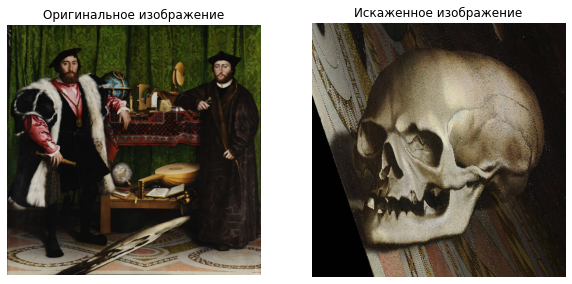

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img1 = cv2.imread("./data/the_ambassadors.jpg")
img2 = cv2.imread("./data/the_ambassadors_skull_transformed.jpg")
 
original_image_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
distorted_image_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)


original_image_rgb = cv2.medianBlur(original_image_rgb, ksize=5)


distorted_image_rgb =  cv2.resize(
    distorted_image_rgb,
    (400, 400),
    interpolation=cv2.INTER_LINEAR,
)

# distorted_image_rgb = cv2.medianBlur(distorted_image_rgb, ksize=5)


# Отображаем оба изображения для выбора контрольных точек
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(original_image_rgb)
plt.title('Оригинальное изображение')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(distorted_image_rgb)
plt.title('Искаженное изображение')
plt.axis('off')

plt.show()





In [20]:
def compute_SIFT(img: np.ndarray) -> tuple[list[cv2.KeyPoint], np.ndarray, np.ndarray]:
    # Initialize ASIFT detector
    # Guoshen Yu and Jean-Michel Morel. Asift: An algorithm for fully affine invariant comparison. Image Processing On Line, 1:11–38, 2011.
    sift = cv2.AffineFeature_create(cv2.SIFT_create())
    # Find keypoints and descriptors
    kp, des = sift.detectAndCompute(img, None)
    img_kp = cv2.drawKeypoints(img, kp, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    return kp, des, img_kp


In [21]:
def match_keypoints(des1: np.ndarray, des2: np.ndarray, ratio_thresh=0.8):
    """
    Находит хорошие сопоставления между двумя наборами дескрипторов
    
    Args:
        des1: Дескрипторы первого изображения
        des2: Дескрипторы второго изображения
        ratio_thresh: Пороговое значение для фильтрации сопоставлений
    
    Returns:
        Список хороших сопоставлений
    """
    # Инициализируем BFMatcher с нормой L2
    bf = cv2.BFMatcher(cv2.NORM_L2)
    
    # Находим k=2 ближайших соседа для каждого дескриптора
    matches_knn = bf.knnMatch(des1, des2, k=2)
    
    # index_params = dict(algorithm=1, trees=5)
    # search_params = dict(checks=50)
    # flann = cv2.FlannBasedMatcher(index_params, search_params)

    # matches_knn = flann.knnMatch(des1, des2, k=2)
    
    good_matches = []
    for m, n in matches_knn:
        if m.distance < ratio_thresh * n.distance:
            good_matches.append(m)
    
    return good_matches

def draw_matches(img1: np.ndarray, kp1: list[cv2.KeyPoint], img2: np.ndarray, kp2: list[cv2.KeyPoint], matches: list[cv2.DMatch]):
    """
    Рисует сопоставления между двумя изображениями
    
    Args:
        img1: Первое изображение
        kp1: Ключевые точки первого изображения
        img2: Второе изображение
        kp2: Ключевые точки второго изображения
        matches: Список сопоставлений
    """
    # Рисуем сопоставления на новом изображении
    img_matches = cv2.drawMatches(img1, kp1, img2, kp2, matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    
    # Отображаем результат
    plt.figure(figsize=(10, 10))
    plt.imshow(img_matches)
    plt.axis('off')
    plt.title("Matches")
    plt.tight_layout()
    plt.show()

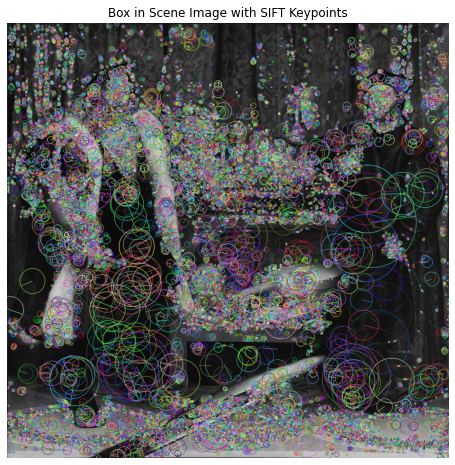

In [22]:
kp, des, img_kp = compute_SIFT(cv2.cvtColor(original_image_rgb,cv2.COLOR_RGB2GRAY ))

# Display the image with keypoints
plt.figure(figsize=(8, 8))
plt.imshow(img_kp)
plt.axis('off')
plt.title("Box in Scene Image with SIFT Keypoints")
plt.show()

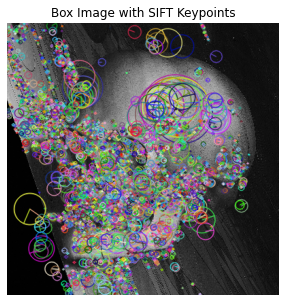

In [23]:
ref_kp, ref_des, ref_img_kp = compute_SIFT(cv2.cvtColor(distorted_image_rgb,cv2.COLOR_RGB2GRAY ))

# Display the image with keypoints
plt.figure(figsize=(5, 5))
plt.imshow(ref_img_kp)
plt.axis('off')
plt.title("Box Image with SIFT Keypoints")
plt.show()

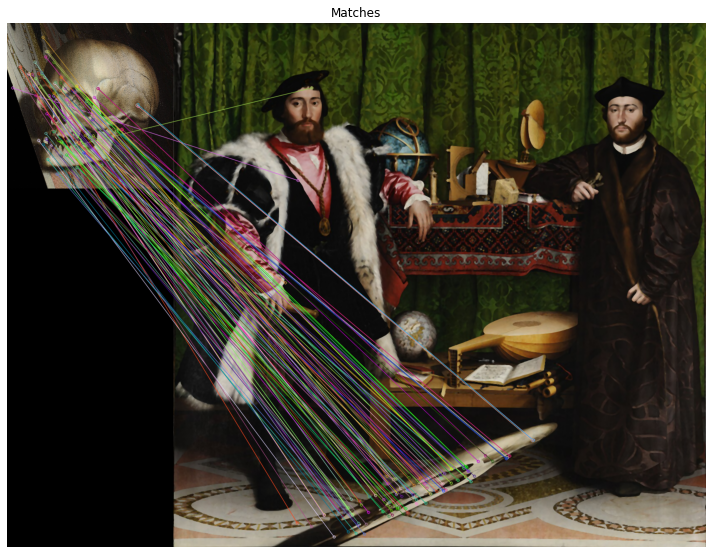

In [24]:
good_matches = match_keypoints(ref_des, des,ratio_thresh=0.65)

draw_matches(distorted_image_rgb, ref_kp, original_image_rgb, kp, good_matches)

# good_matches.sort(key=lambda x: x.distance)

In [25]:
original_points = np.float32([ kp[m.trainIdx].pt for m in good_matches ]).reshape(-1,1,2)
distorted_points = np.float32([ ref_kp[m.queryIdx].pt for m in good_matches ]).reshape(-1,1,2)


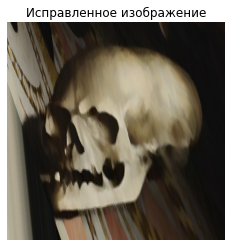

In [26]:
H, mask = cv2.findHomography(original_points,distorted_points, cv2.RANSAC, 5.0)

H_inv = np.linalg.inv(H)
h_temp, w_temp = distorted_image_rgb.shape[:2]
warped_image = cv2.warpPerspective(original_image_rgb, H, (w_temp, h_temp),
                                    flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)
plt.imshow(warped_image)
plt.title('Исправленное изображение')
plt.axis('off')
plt.show()

## Задача 2

Сделайте два фото одного и того же объекта с разных ракурсов.
Теперь **используйте SuperPoint для нахождения ключевых точек** на этих изображениях (веса - возьмите готовые).
Затем **используйте SuperGlue для сопоставления этих ключевых точек**.
Визуализируйте результат.

/home/panzer/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


(-0.5, 809.5, 1079.5, -0.5)

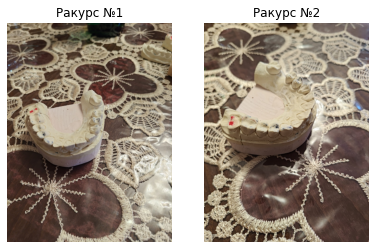

In [3]:
import cv2 
import matplotlib.pyplot as plt

img1_raw = cv2.imread("./data/1.jpg")
img2_raw = cv2.imread("./data/2.jpg")
# img3_raw = cv2.imread("./data/3.jpg")
 
img1 = cv2.cvtColor(img1_raw, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2_raw, cv2.COLOR_BGR2RGB)
# img3 = cv2.cvtColor(img3_raw, cv2.COLOR_BGR2RGB)



# Отображаем оба изображения для выбора контрольных точек
plt.figure(figsize=(10, 5))

plt.subplot(1, 3, 1)
plt.imshow(img1)
plt.title('Ракурс №1')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img2)
plt.title('Ракурс №2')
plt.axis('off')

# plt.subplot(1, 3, 3)
# plt.imshow(img3)
# plt.title('Ракурс №3')
# plt.axis('off')
# plt.show()

To fix superglue:

In [4]:
# !pip uninstall -y transformers 
# !pip install  git+https://github.com/huggingface/transformers.git@abe57b6f17f91acb5adab28b40d0cbc85b497b5f

In [5]:
from transformers import AutoImageProcessor, AutoModel
import torch
from PIL import Image
import requests

images = [img1, img2]

processor = AutoImageProcessor.from_pretrained("magic-leap-community/superglue_indoor")
model = AutoModel.from_pretrained("magic-leap-community/superglue_indoor")

inputs = processor(images, return_tensors="pt")
with torch.no_grad():
    outputs = model(**inputs)

preprocessor_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/53.4M [00:00<?, ?B/s]

In [20]:
image_sizes = [[image.shape[:2] for image in images]]
outputs_1 = processor.post_process_keypoint_matching(outputs, image_sizes,threshold=0.5)
for i, output in enumerate(outputs_1):
    print("For the image pair", i)
    print(output)
    for keypoint0, keypoint1, matching_score in zip(
            output["keypoints0"], output["keypoints1"], output["matching_scores"]
    ):
        print(
            f"Keypoint at coordinate {keypoint0.numpy()} in the first image matches with keypoint at coordinate {keypoint1.numpy()} in the second image with a score of {matching_score}."
        )

For the image pair 0
{'keypoints0': tensor([[298, 423],
        [136, 477],
        [115, 488],
        [407, 542],
        [258, 567]], dtype=torch.int32), 'keypoints1': tensor([[239, 366],
        [225, 499],
        [213, 517],
        [496, 353],
        [406, 479]], dtype=torch.int32), 'matching_scores': tensor([0.7909, 0.6006, 0.5068, 0.6084, 0.7057])}
Keypoint at coordinate [298 423] in the first image matches with keypoint at coordinate [239 366] in the second image with a score of 0.7909409999847412.
Keypoint at coordinate [136 477] in the first image matches with keypoint at coordinate [225 499] in the second image with a score of 0.6005870699882507.
Keypoint at coordinate [115 488] in the first image matches with keypoint at coordinate [213 517] in the second image with a score of 0.5067521333694458.
Keypoint at coordinate [407 542] in the first image matches with keypoint at coordinate [496 353] in the second image with a score of 0.6084001660346985.
Keypoint at coordinate 

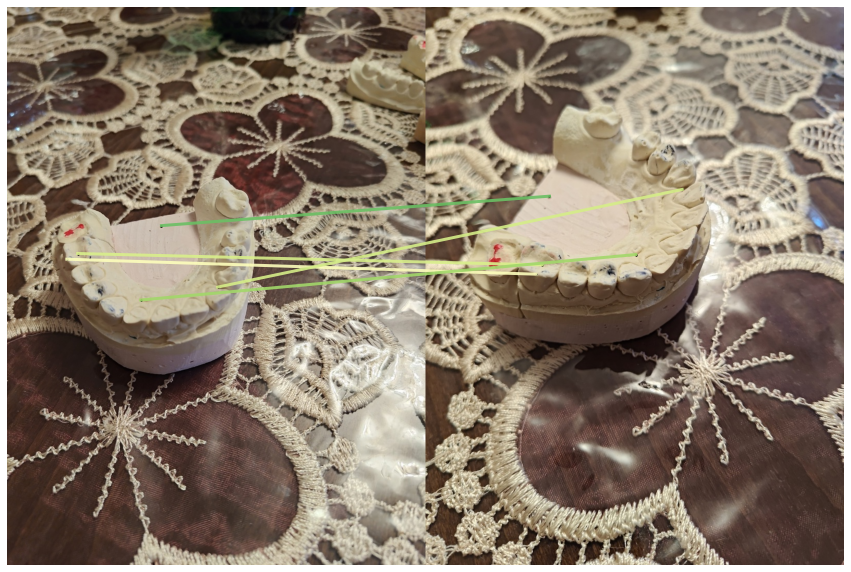

In [21]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15,25)) 

# Create side by side image
merged_image = np.hstack((img1,img2))
plt.imshow(merged_image)
plt.axis("off")

# Retrieve the keypoints and matches
output = outputs_1[0]
keypoints0 = output["keypoints0"]
keypoints1 = output["keypoints1"]
matching_scores = output["matching_scores"]
keypoints0_x, keypoints0_y = keypoints0[:, 0].numpy(), keypoints0[:, 1].numpy()
keypoints1_x, keypoints1_y = keypoints1[:, 0].numpy(), keypoints1[:, 1].numpy()

# Plot the matches
for keypoint0_x, keypoint0_y, keypoint1_x, keypoint1_y, matching_score in zip(
        keypoints0_x, keypoints0_y, keypoints1_x, keypoints1_y, matching_scores
):
    plt.plot(
        [keypoint0_x, keypoint1_x + img1.shape[1]],
        [keypoint0_y, keypoint1_y],
        color=plt.get_cmap("RdYlGn")(matching_score.item()),
        alpha=0.9,
        linewidth=3,
    )
    plt.scatter(keypoint0_x, keypoint0_y, c="black", s=2)
    plt.scatter(keypoint1_x + img1.shape[1], keypoint1_y, c="black", s=2)

# Save the plot
plt.show()

## Задание 3 (исследовательское)

Найдите свежий нейросетевой метод (2023 и моложе), реализующий детекцию и сопоставление ключевых точек (можно два метода, если они работают последовательно).
Напишите краткий обзор этого метода:
- Краткое описание (summary);
- Достоинства метода;
- Недостатки метода.

Ответ (обзор) - пишите в Markdown ячейке в этом ноутбуке.

## Обзор метода детекции и сопоставления ключевых точек
https://arxiv.org/pdf/2402.11095

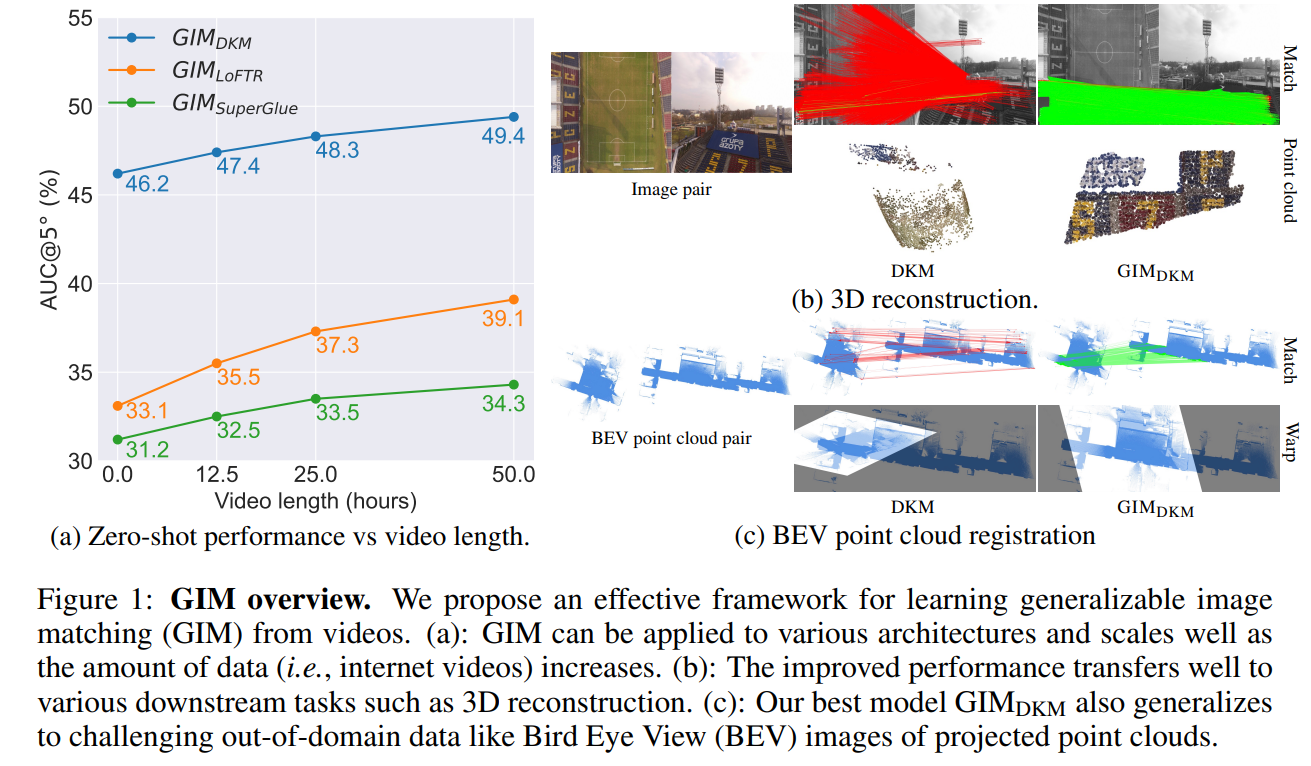

## GIM: LEARNING GENERALIZABLE IMAGE MATCHER FROM INTERNET VIDEOS
### Краткое описание (Summary)
GIM — это метод самообучения (self-training) для создания универсального сопоставителя изображений на основе интернет-видео. В отличие от традиционных подходов, требующих раздельного обучения для разных типов сцен (например, indoor/outdoor), GIM использует разнообразные видеоданные для генерации меток и обучения единой модели. 

TLDR: Детекторы (superglue, dkm, LoFTR) обучаются на видео с ютуба, которые они сами разметили, + данные аугументируются при помощи преобразований перспектив и тд. Это улучшает обобщающие способности сетей. 

Основные шаги:

1) Предобучение модели на стандартных датасетах (например, MegaDepth, ScanNet).

2) Генерация плотных соответствий между кадрами видео с помощью комбинации предобученной модели и дополнительных методов (например, RootSIFT).

3) Фильтрация выбросов (robust fitting) и распространение меток на далекие кадры (propagation).

4) Финальное обучение с сильными аугментациями для улучшения обобщаемости.

### Достоинства метода
- **✅ Универсальность**: Одна модель работает на разных типах сцен (indoor/outdoor, BEV-изображения и др.).
- **✅ Масштабируемость**: Использует практически неограниченные интернет-видео вместо дорогих 3D-реконструкций.
- **✅ Совместимость**: Применим к разным архитектурам (SuperGlue, LoFTR, DKM).
- **✅ Улучшенная обобщаемость**: Показывает лучшие zero-shot-результаты на разнородных данных (например, +18.1% AUC для LoFTR).
- **✅ Применимость в downstream-задачах**:Улучшает 3D-реконструкцию, локализацию и оценку гомографии 



### Недостатки метода
- **❌ Зависимость от качества видео**: Шумные или низкокачественные видео могут ухудшить генерацию меток.
- **❌ Вычислительная сложность**: Требует значительных ресурсов для обработки больших объемов видео (например, 16 GPU на 4 дня для 50 часов видео).
- **❌ Ограниченный контроль над данными**: Автоматическая генерация меток может пропускать ошибки, которые сложно исправить без ручной проверки.
- **❌ Недостаточная адаптация к экстремальным случаям**: Хотя метод обобщается лучше, чем аналоги, сложные сцены (например, сильные искажения или динамические объекты) могут оставаться проблемой.
